# Analyze Vilin97/KilterBoard dataset

In [ ]:
!pip -q install huggingface_hub pandas numpy torch tqdm

download the SQLite dataset

In [ ]:
from pathlib import Path
from huggingface_hub import hf_hub_download

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

DB_PATH = hf_hub_download(
    repo_id="Vilin97/KilterBoard",
    filename="kilter_splits.sqlite",
    repo_type="dataset",
    local_dir=str(DATA_DIR),
)

print("Downloaded DB to:", DB_PATH)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


kilter_splits.sqlite:   0%|          | 0.00/124M [00:00<?, ?B/s]

Downloaded DB to: /content/data/kilter_splits.sqlite


In [ ]:
import sqlite3
import pandas as pd
import json
import re

conn = sqlite3.connect(DB_PATH)
def q(query):
    return pd.read_sql_query(query, conn)

# Fetch placements
placements_xy = q("""
SELECT
  p.id AS placementId,
  p.hole_id AS holeId,
  h.x AS x,
  h.y AS y,
  p.layout_id,
  p.set_id
FROM placements p
JOIN holes h ON h.id = p.hole_id
WHERE p.layout_id = 1
  AND p.set_id IN (1, 20)
  AND h.x BETWEEN 0 AND 144
  AND h.y BETWEEN 0 AND 176
ORDER BY p.id;
""")

valid_placement_ids = set(placements_xy['placementId'])

# Find a random climb within constraints
random_climbs_df = q("""
SELECT uuid, name, frames
FROM kilter_train
WHERE layout_id = 1 AND frames IS NOT NULL
ORDER BY RANDOM()
LIMIT 1000;
""")

formatted_climb = []
for _, row in random_climbs_df.iterrows():
    frames_str = row['frames']
    # Parse the frames string format (e.g., p1149r13p1179r12)
    matches = re.findall(r'p(\d+)r(\d+)', frames_str)
    holds = [{'placementId': int(p), 'roleId': int(r)} for p, r in matches]

    # Check if all holds in this climb are within our valid placements constraints
    if holds and all(h['placementId'] in valid_placement_ids for h in holds):
        print(f"Found matching random climb: {row['name']}")
        formatted_climb = holds
        break

print(json.dumps(formatted_climb, indent=2))


Found matching random climb: Gorilla Pizza
[
  {
    "placementId": 1148,
    "roleId": 12
  },
  {
    "placementId": 1152,
    "roleId": 15
  },
  {
    "placementId": 1214,
    "roleId": 12
  },
  {
    "placementId": 1236,
    "roleId": 13
  },
  {
    "placementId": 1270,
    "roleId": 13
  },
  {
    "placementId": 1286,
    "roleId": 13
  },
  {
    "placementId": 1316,
    "roleId": 13
  },
  {
    "placementId": 1334,
    "roleId": 13
  },
  {
    "placementId": 1366,
    "roleId": 13
  },
  {
    "placementId": 1388,
    "roleId": 14
  }
]


In [ ]:
# Query for all climbs with layout_id = 1
train_df = q("""
SELECT *
FROM kilter_train
WHERE layout_id = 1
""")

test_df = q("""
SELECT *
FROM kilter_test
WHERE layout_id = 1
""")

val_df = q("""
SELECT *
FROM kilter_val
WHERE layout_id = 1
""")

# Save to CSV
train_df.to_csv('/content/kilter_train.csv', index=False)
test_df.to_csv('/content/kilter_test.csv', index=False)
val_df.to_csv('/content/kilter_val.csv', index=False)

# SplitSummary.json
split_summary = {
    "train": {
        "rows": len(train_df),
        "unique_uuids": train_df["uuid"].nunique()
    },
    "test": {
        "rows": len(test_df),
        "unique_uuids": test_df["uuid"].nunique()
    },
    "val": {
        "rows": len(val_df),
        "unique_uuids": val_df["uuid"].nunique()
    },
    "uuid_overlap": {
        "train_test": len(set(train_df["uuid"]) & set(test_df["uuid"])),
        "train_val": len(set(train_df["uuid"]) & set(val_df["uuid"])),
        "test_val": len(set(test_df["uuid"]) & set(val_df["uuid"]))
    }
}

split_summary

{'train': {'rows': 190439, 'unique_uuids': 116125},
 'test': {'rows': 23787, 'unique_uuids': 14517},
 'val': {'rows': 23676, 'unique_uuids': 14515},
 'uuid_overlap': {'train_test': 0, 'train_val': 0, 'test_val': 0}}

In [ ]:
all_climbs_df = q("""
SELECT difficulty_numeric, boulder_grade FROM kilter_train WHERE layout_id = 1
UNION ALL
SELECT difficulty_numeric, boulder_grade FROM kilter_test WHERE layout_id = 1
UNION ALL
SELECT difficulty_numeric, boulder_grade FROM kilter_val WHERE layout_id = 1
""")

mapping_df = all_climbs_df[['difficulty_numeric', 'boulder_grade']].drop_duplicates().dropna().sort_values('difficulty_numeric')
display(mapping_df)

,difficulty_numeric,boulder_grade
12301,10.0000,4a/V0
848,10.0080,4a/V0
821,10.0105,4a/V0
456,10.0111,4a/V0
867,10.0127,4a/V0
...,...,...
107707,30.5000,8b/V13
65281,30.6667,8b+/V14
53352,30.7500,8b+/V14
212643,30.8571,8b+/V14


In [ ]:
def get_boulder_grade(numeric_val, mapping_df=mapping_df):
    """Returns the V-grade portion for a given numeric difficulty."""
    import re
    # Find the index of the row with the closest difficulty_numeric
    closest_idx = (mapping_df['difficulty_numeric'] - numeric_val).abs().idxmin()
    full_grade = mapping_df.loc[closest_idx, 'boulder_grade']

    # Use regex to extract the part starting with V (e.g., V8, V13)
    match = re.search(r'(V\d+)', full_grade)
    return match.group(1) if match else full_grade

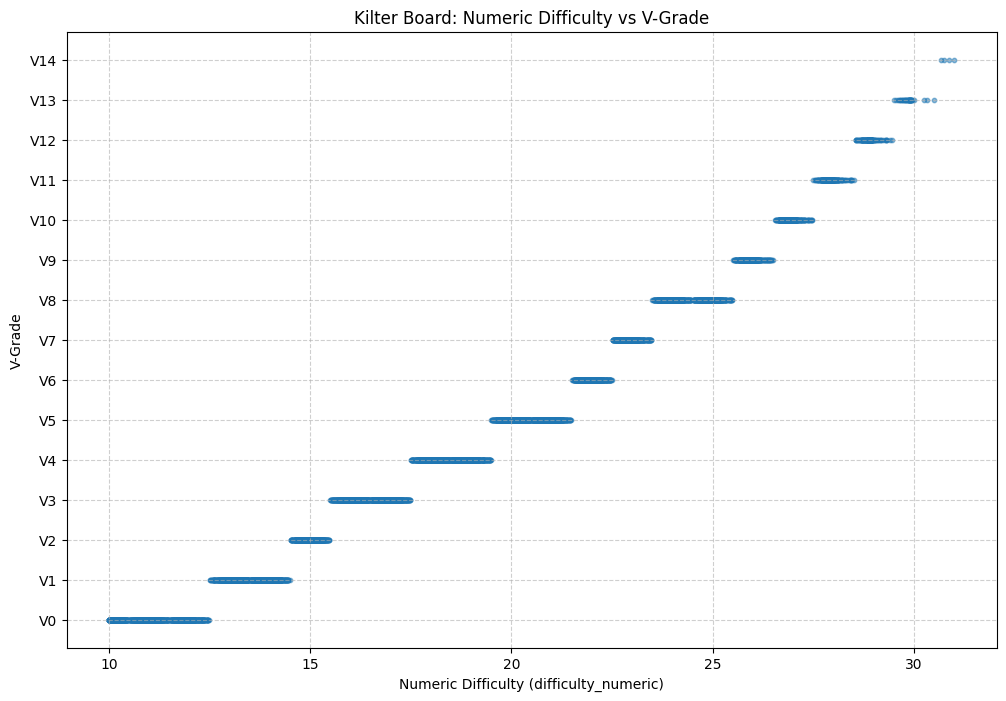

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
plot_df = mapping_df.copy()
# Apply the conversion to get clean V-grades for the y-axis
plot_df['v_grade'] = plot_df['difficulty_numeric'].apply(get_boulder_grade)

# Sort by difficulty_numeric to ensure the V-grades appear in order on the axis
plot_df = plot_df.sort_values('difficulty_numeric')

plt.figure(figsize=(12, 8))
plt.scatter(plot_df['difficulty_numeric'], plot_df['v_grade'], alpha=0.5, s=10)

plt.title('Kilter Board: Numeric Difficulty vs V-Grade')
plt.xlabel('Numeric Difficulty (difficulty_numeric)')
plt.ylabel('V-Grade')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust y-axis to show grades in order
unique_grades = plot_df['v_grade'].unique()
plt.yticks(unique_grades)

plt.show()

In [ ]:
import pandas as pd

# Group by V-grade and calculate range statistics
grade_ranges = plot_df.groupby('v_grade')['difficulty_numeric'].agg(['min', 'max', 'mean', 'count'])

# Sort by the average difficulty to keep grades in logical order (V0, V1, etc.)
grade_ranges = grade_ranges.sort_values('mean')

print("Difficulty Numeric Ranges by V-Grade:")
display(grade_ranges)

Difficulty Numeric Ranges by V-Grade:


,min,max,mean,count
v_grade,,,,
V0,10.0000,12.5000,11.079503,1483
V1,12.5200,14.5000,13.492444,1336
V2,14.5217,15.4628,14.984350,828
V3,15.5000,17.4742,16.418778,1927
V4,17.5000,19.4829,18.388302,1891
V5,19.5000,21.4706,20.362638,1883
V6,21.5000,22.5000,21.943961,1228
V7,22.5122,23.4762,22.919262,1024
V8,23.5000,25.4915,24.298018,1461


In [ ]:
!curl -o /content/BoardPlacements.json https://raw.githubusercontent.com/Paracosms/kilter-ml-generator/refs/heads/master/web/src/Data/BoardPlacements.json

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 57283  100 57283    0     0   269k      0 --:--:-- --:--:-- --:--:--  270k


metadata preprocessing

In [ ]:
import numpy as np
import json
import torch
import re
from collections import Counter

with open('/content/BoardPlacements.json', 'r', encoding='utf-8-sig') as f:
    board_data = json.load(f)

placement_to_xy = {
    int(p['placementId']): (float(p.get('x', 0.0)), float(p.get('y', 0.0)))
    for p in board_data
}

board_x_min = min(x for x, _ in placement_to_xy.values())
board_x_max = max(x for x, _ in placement_to_xy.values())
board_y_min = min(y for _, y in placement_to_xy.values())
board_y_max = max(y for _, y in placement_to_xy.values())
board_x_span = max(board_x_max - board_x_min, 1.0)
board_y_span = max(board_y_max - board_y_min, 1.0)

HAND_ROLES = {12, 13, 14}
FOOT_ROLE = 15
NEARBY_FOOT_DISTANCE = 16.0

METADATA_FEATURE_NAMES = [
    "total_hold_count",
    "hand_hold_count",
    "start_count",
    "regular_count",
    "foot_count",
    "finish_count",
    "foot_ratio",
    "regular_ratio",
    "min_x",
    "max_x",
    "min_y",
    "max_y",
    "x_spread",
    "y_spread",
    "bounding_box_area",
    "aspect_ratio",
    "mean_x",
    "mean_y",
    "std_x",
    "std_y",
    "hand_min_x",
    "hand_max_x",
    "hand_min_y",
    "hand_max_y",
    "hand_x_spread",
    "hand_y_spread",
    "hand_mean_x",
    "hand_mean_y",
    "hand_std_x",
    "hand_std_y",
    "start_mean_x",
    "start_mean_y",
    "finish_mean_x",
    "finish_mean_y",
    "start_to_finish_dx",
    "start_to_finish_dy",
    "start_to_finish_abs_dx",
    "start_to_finish_abs_dy",
    "start_to_finish_distance",
    "mean_pairwise_distance",
    "median_pairwise_distance",
    "min_pairwise_distance",
    "max_pairwise_distance",
    "std_pairwise_distance",
    "mean_nearest_neighbor_distance",
    "max_nearest_neighbor_distance",
    "hand_mean_nearest_neighbor_distance",
    "hand_max_nearest_neighbor_distance",
    "start_to_nearest_regular_distance",
    "finish_to_nearest_regular_distance",
    "start_to_nearest_foot_distance",
    "finish_to_nearest_foot_distance",
    "foot_mean_x",
    "foot_mean_y",
    "foot_x_spread",
    "foot_y_spread",
    "mean_foot_to_nearest_hand_distance",
    "hands_with_nearby_foot_ratio",
    "left_hold_ratio",
    "center_hold_ratio",
    "right_hold_ratio",
    "bottom_third_hold_ratio",
    "middle_third_hold_ratio",
    "top_third_hold_ratio",
    "occupied_zone_count",
    "max_zone_hold_count",
]


def _safe_div(numerator, denominator):
    return float(numerator) / float(denominator) if denominator else 0.0


def _coords_for_roles(records, roles):
    points = [(x, y) for x, y, role_id in records if role_id in roles]
    if not points:
        return np.empty(0, dtype=np.float32), np.empty(0, dtype=np.float32)
    arr = np.asarray(points, dtype=np.float32)
    return arr[:, 0], arr[:, 1]


def _coord_summary(xs, ys):
    if xs.size == 0:
        return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    min_x = float(np.min(xs))
    max_x = float(np.max(xs))
    min_y = float(np.min(ys))
    max_y = float(np.max(ys))
    return (
        min_x,
        max_x,
        min_y,
        max_y,
        max_x - min_x,
        max_y - min_y,
        float(np.mean(xs)),
        float(np.mean(ys)),
    )


def _coord_spread_std(xs, ys):
    if xs.size == 0:
        return 0.0, 0.0
    return float(np.std(xs)), float(np.std(ys))


def _pairwise_distances(xs, ys):
    if xs.size < 2:
        return np.empty(0, dtype=np.float32)
    coords = np.column_stack((xs, ys)).astype(np.float32)
    diffs = coords[:, None, :] - coords[None, :, :]
    distances = np.sqrt(np.sum(diffs * diffs, axis=-1))
    return distances[np.triu_indices(coords.shape[0], k=1)]


def _nearest_neighbor_distances(xs, ys):
    if xs.size == 0:
        return np.empty(0, dtype=np.float32)
    if xs.size == 1:
        return np.zeros(1, dtype=np.float32)
    coords = np.column_stack((xs, ys)).astype(np.float32)
    diffs = coords[:, None, :] - coords[None, :, :]
    distances = np.sqrt(np.sum(diffs * diffs, axis=-1))
    np.fill_diagonal(distances, np.inf)
    return np.min(distances, axis=1).astype(np.float32)


def _cross_min_distance(xs_a, ys_a, xs_b, ys_b):
    if xs_a.size == 0 or xs_b.size == 0:
        return 0.0
    a = np.column_stack((xs_a, ys_a)).astype(np.float32)
    b = np.column_stack((xs_b, ys_b)).astype(np.float32)
    diffs = a[:, None, :] - b[None, :, :]
    distances = np.sqrt(np.sum(diffs * diffs, axis=-1))
    return float(np.min(distances))


def _cross_nearest_distances(xs_a, ys_a, xs_b, ys_b):
    if xs_a.size == 0 or xs_b.size == 0:
        return np.empty(0, dtype=np.float32)
    a = np.column_stack((xs_a, ys_a)).astype(np.float32)
    b = np.column_stack((xs_b, ys_b)).astype(np.float32)
    diffs = a[:, None, :] - b[None, :, :]
    distances = np.sqrt(np.sum(diffs * diffs, axis=-1))
    return np.min(distances, axis=1).astype(np.float32)


def _extract_hold_records(problem):
    frames_str = str(problem.get('frames', '') or '')
    frames_xy_str = str(problem.get('frames_xy', '') or '')
    frame_matches = re.findall(r'p(\d+)r(\d+)', frames_str)
    xy_matches = re.findall(r'\((-?\d+),(-?\d+)\)[A-Za-z]', frames_xy_str)

    records = []
    for idx, (p_id, r_id) in enumerate(frame_matches):
        p_id_int = int(p_id)
        r_id_int = int(r_id)
        coords = placement_to_xy.get(p_id_int)
        if coords is None:
            continue
        if idx < len(xy_matches):
            x, y = float(xy_matches[idx][0]), float(xy_matches[idx][1])
        else:
            x, y = coords
        records.append((x, y, r_id_int))
    return records

placement_to_idx = {int(p['placementId']): i for i, p in enumerate(board_data)}
num_placements = len(placement_to_idx)

# Role mapping
role_to_channel = {
    12: 0, # start
    13: 1, # regular
    14: 2, # finish
    15: 3  # foot
}

setup datasets for training

In [ ]:

def flatten_climb_multihot(problem, mapping=placement_to_idx):
    """
    Converts a problem row (Series/Dict) into a (5, 565) tensor.
    Channels: 0=start, 1=regular, 2=finish, 3=foot, 4=metadata
    """
    tensor = np.zeros((5, num_placements), dtype=np.float32)

    # Access frames string from the row
    frames_str = problem['frames']
    matches = re.findall(r'p(\d+)r(\d+)', frames_str)

    for p_id, r_id in matches:
        p_id_int = int(p_id)
        r_id_int = int(r_id)
        if p_id_int in mapping and r_id_int in role_to_channel:
            channel_idx = role_to_channel[r_id_int]
            placement_idx = mapping[p_id_int]
            tensor[channel_idx, placement_idx] = 1.0

    records = _extract_hold_records(problem)
    total_hold_count = len(records)

    start_xs, start_ys = _coords_for_roles(records, {12})
    regular_xs, regular_ys = _coords_for_roles(records, {13})
    finish_xs, finish_ys = _coords_for_roles(records, {14})
    foot_xs, foot_ys = _coords_for_roles(records, {15})
    hand_xs, hand_ys = _coords_for_roles(records, HAND_ROLES)

    start_count = int(start_xs.size)
    regular_count = int(regular_xs.size)
    finish_count = int(finish_xs.size)
    foot_count = int(foot_xs.size)
    hand_hold_count = int(start_count + regular_count + finish_count)

    min_x, max_x, min_y, max_y, x_spread, y_spread, mean_x, mean_y = _coord_summary(
        np.asarray([x for x, _, _ in records], dtype=np.float32),
        np.asarray([y for _, y, _ in records], dtype=np.float32),
    )
    std_x, std_y = _coord_spread_std(
        np.asarray([x for x, _, _ in records], dtype=np.float32),
        np.asarray([y for _, y, _ in records], dtype=np.float32),
    )

    hand_min_x, hand_max_x, hand_min_y, hand_max_y, hand_x_spread, hand_y_spread, hand_mean_x, hand_mean_y = _coord_summary(
        hand_xs, hand_ys
    )
    hand_std_x, hand_std_y = _coord_spread_std(hand_xs, hand_ys)

    start_mean_x, start_mean_y = (float(np.mean(start_xs)), float(np.mean(start_ys))) if start_xs.size else (0.0, 0.0)
    finish_mean_x, finish_mean_y = (float(np.mean(finish_xs)), float(np.mean(finish_ys))) if finish_xs.size else (0.0, 0.0)

    start_to_finish_dx = finish_mean_x - start_mean_x
    start_to_finish_dy = finish_mean_y - start_mean_y
    start_to_finish_abs_dx = abs(start_to_finish_dx)
    start_to_finish_abs_dy = abs(start_to_finish_dy)
    start_to_finish_distance = float(np.hypot(start_to_finish_dx, start_to_finish_dy))

    pairwise_distances = _pairwise_distances(
        np.asarray([x for x, _, _ in records], dtype=np.float32),
        np.asarray([y for _, y, _ in records], dtype=np.float32),
    )
    if pairwise_distances.size:
        mean_pairwise_distance = float(np.mean(pairwise_distances))
        median_pairwise_distance = float(np.median(pairwise_distances))
        min_pairwise_distance = float(np.min(pairwise_distances))
        max_pairwise_distance = float(np.max(pairwise_distances))
        std_pairwise_distance = float(np.std(pairwise_distances))
    else:
        mean_pairwise_distance = 0.0
        median_pairwise_distance = 0.0
        min_pairwise_distance = 0.0
        max_pairwise_distance = 0.0
        std_pairwise_distance = 0.0

    nearest_neighbor_distances = _nearest_neighbor_distances(
        np.asarray([x for x, _, _ in records], dtype=np.float32),
        np.asarray([y for _, y, _ in records], dtype=np.float32),
    )
    mean_nearest_neighbor_distance = float(np.mean(nearest_neighbor_distances)) if nearest_neighbor_distances.size else 0.0
    max_nearest_neighbor_distance = float(np.max(nearest_neighbor_distances)) if nearest_neighbor_distances.size else 0.0

    hand_nearest_neighbor_distances = _nearest_neighbor_distances(hand_xs, hand_ys)
    hand_mean_nearest_neighbor_distance = float(np.mean(hand_nearest_neighbor_distances)) if hand_nearest_neighbor_distances.size else 0.0
    hand_max_nearest_neighbor_distance = float(np.max(hand_nearest_neighbor_distances)) if hand_nearest_neighbor_distances.size else 0.0

    start_to_nearest_regular_distance = _cross_min_distance(start_xs, start_ys, regular_xs, regular_ys)
    finish_to_nearest_regular_distance = _cross_min_distance(finish_xs, finish_ys, regular_xs, regular_ys)
    start_to_nearest_foot_distance = _cross_min_distance(start_xs, start_ys, foot_xs, foot_ys)
    finish_to_nearest_foot_distance = _cross_min_distance(finish_xs, finish_ys, foot_xs, foot_ys)

    foot_mean_x = float(np.mean(foot_xs)) if foot_xs.size else 0.0
    foot_mean_y = float(np.mean(foot_ys)) if foot_ys.size else 0.0
    foot_min_x, foot_max_x, foot_min_y, foot_max_y, foot_x_spread, foot_y_spread, _, _ = _coord_summary(foot_xs, foot_ys)

    if foot_xs.size and hand_xs.size:
        hand_to_foot_distances = _cross_nearest_distances(hand_xs, hand_ys, foot_xs, foot_ys)
        mean_foot_to_nearest_hand_distance = float(np.mean(_cross_nearest_distances(foot_xs, foot_ys, hand_xs, hand_ys)))
        hands_with_nearby_foot_ratio = _safe_div(np.sum(hand_to_foot_distances <= NEARBY_FOOT_DISTANCE), hand_hold_count)
    else:
        mean_foot_to_nearest_hand_distance = 0.0
        hands_with_nearby_foot_ratio = 0.0

    x_left = board_x_min + (board_x_span / 3.0)
    x_right = board_x_min + (2.0 * board_x_span / 3.0)
    y_bottom = board_y_min + (board_y_span / 3.0)
    y_top = board_y_min + (2.0 * board_y_span / 3.0)

    if total_hold_count:
        left_hold_ratio = _safe_div(np.sum(np.asarray([x for x, _, _ in records], dtype=np.float32) < x_left), total_hold_count)
        center_hold_ratio = _safe_div(np.sum((np.asarray([x for x, _, _ in records], dtype=np.float32) >= x_left) & (np.asarray([x for x, _, _ in records], dtype=np.float32) < x_right)), total_hold_count)
        right_hold_ratio = _safe_div(np.sum(np.asarray([x for x, _, _ in records], dtype=np.float32) >= x_right), total_hold_count)

        bottom_third_hold_ratio = _safe_div(np.sum(np.asarray([y for _, y, _ in records], dtype=np.float32) < y_bottom), total_hold_count)
        middle_third_hold_ratio = _safe_div(np.sum((np.asarray([y for _, y, _ in records], dtype=np.float32) >= y_bottom) & (np.asarray([y for _, y, _ in records], dtype=np.float32) < y_top)), total_hold_count)
        top_third_hold_ratio = _safe_div(np.sum(np.asarray([y for _, y, _ in records], dtype=np.float32) >= y_top), total_hold_count)
    else:
        left_hold_ratio = center_hold_ratio = right_hold_ratio = 0.0
        bottom_third_hold_ratio = middle_third_hold_ratio = top_third_hold_ratio = 0.0

    if total_hold_count:
        x_bins = np.digitize(np.asarray([x for x, _, _ in records], dtype=np.float32), [x_left, x_right], right=False)
        y_bins = np.digitize(np.asarray([y for _, y, _ in records], dtype=np.float32), [y_bottom, y_top], right=False)
        zone_counts = Counter(zip(x_bins.tolist(), y_bins.tolist()))
        occupied_zone_count = len(zone_counts)
        max_zone_hold_count = max(zone_counts.values())
    else:
        occupied_zone_count = 0
        max_zone_hold_count = 0

    metadata_values = np.asarray([
        float(total_hold_count),
        float(hand_hold_count),
        float(start_count),
        float(regular_count),
        float(foot_count),
        float(finish_count),
        _safe_div(foot_count, total_hold_count),
        _safe_div(regular_count, hand_hold_count),
        _safe_div(float(problem['angle']), 70),
        min_x,
        max_x,
        min_y,
        max_y,
        x_spread,
        y_spread,
        x_spread * y_spread,
        _safe_div(x_spread, y_spread),
        mean_x,
        mean_y,
        std_x,
        std_y,
        hand_min_x,
        hand_max_x,
        hand_min_y,
        hand_max_y,
        hand_x_spread,
        hand_y_spread,
        hand_mean_x,
        hand_mean_y,
        hand_std_x,
        hand_std_y,
        start_mean_x,
        start_mean_y,
        finish_mean_x,
        finish_mean_y,
        start_to_finish_dx,
        start_to_finish_dy,
        start_to_finish_abs_dx,
        start_to_finish_abs_dy,
        start_to_finish_distance,
        mean_pairwise_distance,
        median_pairwise_distance,
        min_pairwise_distance,
        max_pairwise_distance,
        std_pairwise_distance,
        mean_nearest_neighbor_distance,
        max_nearest_neighbor_distance,
        hand_mean_nearest_neighbor_distance,
        hand_max_nearest_neighbor_distance,
        start_to_nearest_regular_distance,
        finish_to_nearest_regular_distance,
        start_to_nearest_foot_distance,
        finish_to_nearest_foot_distance,
        foot_mean_x,
        foot_mean_y,
        foot_x_spread,
        foot_y_spread,
        mean_foot_to_nearest_hand_distance,
        hands_with_nearby_foot_ratio,
        left_hold_ratio,
        center_hold_ratio,
        right_hold_ratio,
        bottom_third_hold_ratio,
        middle_third_hold_ratio,
        top_third_hold_ratio,
        float(occupied_zone_count),
        float(max_zone_hold_count),
    ], dtype=np.float32)

    metadata_len = min(metadata_values.size, tensor.shape[1])
    tensor[4, :metadata_len] = np.clip(metadata_values[:metadata_len], 0.0, 1.0)

    return tensor


In [ ]:
import tqdm

print(f"Flattening {len(train_df)} climbs with metadata...")
X_train = np.stack([flatten_climb_multihot(row) for _, row in tqdm.tqdm(train_df.iterrows(), total=len(train_df))])
y_train = train_df['difficulty_numeric'].values

print(f"Flattening {len(test_df)} test climbs...")
X_test = np.stack([flatten_climb_multihot(row) for _, row in tqdm.tqdm(test_df.iterrows(), total=len(test_df))])
y_test = test_df['difficulty_numeric'].values

print(f"Flattening {len(val_df)} validation climbs...")
X_val = np.stack([flatten_climb_multihot(row) for _, row in tqdm.tqdm(val_df.iterrows(), total=len(val_df))])
y_val = val_df['difficulty_numeric'].values

print(f"\nTrain input shape: {X_train.shape}")
print(f"Test input shape: {X_test.shape}")
print(f"Validation input shape: {X_val.shape}")

Flattening 190439 climbs with metadata...


100%|██████████| 190439/190439 [03:48<00:00, 832.28it/s]


Flattening 23787 test climbs...


100%|██████████| 23787/23787 [00:28<00:00, 841.45it/s]


Flattening 23676 validation climbs...


100%|██████████| 23676/23676 [00:28<00:00, 843.67it/s]



Train input shape: (190439, 5, 565)
Test input shape: (23787, 5, 565)
Validation input shape: (23676, 5, 565)


In [ ]:
import pandas as pd

def check_metadata_normalization(name, X):
    # Metadata is stored in channel 4 (the 5th channel)
    metadata_slice = X[:, 4, :]

    # Only check indices that correspond to defined feature names
    num_features = len(METADATA_FEATURE_NAMES)
    metadata_slice = metadata_slice[:, :num_features]

    min_vals = metadata_slice.min(axis=0)
    max_vals = metadata_slice.max(axis=0)

    df_check = pd.DataFrame({
        'Feature': METADATA_FEATURE_NAMES,
        'Min': min_vals,
        'Max': max_vals
    })

    print(f"\nNormalization Check for {name}:")
    display(df_check)

    out_of_bounds = df_check[(df_check['Min'] < 0) | (df_check['Max'] > 1)]
    if not out_of_bounds.empty:
        print(f"Warning: {len(out_of_bounds)} features in {name} are outside [0, 1] range.")
    else:
        print(f"All features in {name} are within [0, 1].")

# Check all datasets
check_metadata_normalization("X_train", X_train)
if 'X_test' in locals(): check_metadata_normalization("X_test", X_test)
if 'X_val' in locals(): check_metadata_normalization("X_val", X_val)


Normalization Check for X_train:


,Feature,Min,Max
0,total_hold_count,1.000000,1.000000
1,hand_hold_count,1.000000,1.000000
2,start_count,0.000000,1.000000
3,regular_count,0.000000,1.000000
4,foot_count,0.000000,1.000000
...,...,...,...
61,bottom_third_hold_ratio,0.000000,1.000000
62,middle_third_hold_ratio,0.028571,1.000000
63,top_third_hold_ratio,0.000000,0.971429
64,occupied_zone_count,0.000000,0.971429


All features in X_train are within [0, 1].

Normalization Check for X_test:


,Feature,Min,Max
0,total_hold_count,1.000000,1.000000
1,hand_hold_count,1.000000,1.000000
2,start_count,0.000000,1.000000
3,regular_count,0.000000,1.000000
4,foot_count,0.000000,1.000000
...,...,...,...
61,bottom_third_hold_ratio,0.000000,1.000000
62,middle_third_hold_ratio,0.028571,1.000000
63,top_third_hold_ratio,0.000000,0.942857
64,occupied_zone_count,0.000000,0.750000


All features in X_test are within [0, 1].

Normalization Check for X_val:


,Feature,Min,Max
0,total_hold_count,1.000000,1.000000
1,hand_hold_count,1.000000,1.000000
2,start_count,0.000000,1.000000
3,regular_count,0.000000,1.000000
4,foot_count,0.000000,1.000000
...,...,...,...
61,bottom_third_hold_ratio,0.000000,1.000000
62,middle_third_hold_ratio,0.037037,1.000000
63,top_third_hold_ratio,0.000000,0.900000
64,occupied_zone_count,0.000000,0.818182


All features in X_val are within [0, 1].


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

class ClimbDataset(Dataset):
    def __init__(self, X, y):
        # Flatten the (4, 565) shape to a 1D vector per climb for the MLP
        self.X = torch.tensor(X, dtype=torch.float32).view(X.shape[0], -1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 256

train_dataset = ClimbDataset(X_train, y_train)
test_dataset = ClimbDataset(X_test, y_test)
val_dataset = ClimbDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class ClimbMLP(nn.Module):
    def __init__(self, input_size):
        super(ClimbMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1] * X_train.shape[2] # 4 * 565 = 2260
model = ClimbMLP(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)

ClimbMLP(
  (network): Sequential(
    (0): Linear(in_features=2825, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [ ]:
import random
import copy

# no need for this cell, since we determined best seed = 14
run_cell = False

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Tracking variables for the seed search
best_overall_rmse = float('inf')
best_seed = -1

# Loop through seeds 0 to 20
if run_cell:
    for current_seed in range(21):
        print(f"\n>>> Testing Seed: {current_seed} <<<")
        set_seed(current_seed)

        # Re-initialize model and optimizer for each seed
        model = ClimbMLP(input_dim).to(device)
        criterion = nn.HuberLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        num_epochs = 10
        seed_best_rmse = float('inf')

        for epoch in range(num_epochs):
            model.train()
            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

            # Validation phase
            model.eval()
            epoch_val_mse = 0.0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    outputs = model(inputs)
                    epoch_val_mse += torch.pow(outputs - targets, 2).sum().item()

            epoch_val_rmse = (epoch_val_mse / len(val_loader.dataset)) ** 0.5

            if epoch_val_rmse < seed_best_rmse:
                seed_best_rmse = epoch_val_rmse

        print(f"Seed {current_seed} Best Val RMSE: {seed_best_rmse:.4f}")

        # Track the globally best seed
        if seed_best_rmse < best_overall_rmse:
            best_overall_rmse = seed_best_rmse
            best_seed = current_seed
            torch.save(model.state_dict(), 'best_seed_model.pth')

    # ran 20 seeds, seed 14 was best
    print("\n=========================================")
    print(f"SEARCH COMPLETE")
    print(f"Best Seed Found: {best_seed}")
    print(f"Lowest RMSE: {best_overall_rmse:.4f}")
    print("=========================================")

In [ ]:
set_seed(14)

# Re-initialize model and optimizer
model = ClimbMLP(input_dim).to(device)
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
seed_best_rmse = float('inf')

for epoch in range(num_epochs):
    model.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

    # Validation phase
    model.eval()
    epoch_val_mse = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            epoch_val_mse += torch.pow(outputs - targets, 2).sum().item()

    epoch_val_rmse = (epoch_val_mse / len(val_loader.dataset)) ** 0.5

Calculated Validation MAE: 1.5673
Interpretation:
Where the blue error bars overlap multiple gray sections, the model may confuse those grades.


,median,points_to_next,mae_in_this_grade_units
v_grade,,,
V0,11.03230,2.39450,0.654549
V1,13.42680,1.55425,1.008408
V2,14.98105,1.27145,1.232702
V3,16.25250,1.95340,0.802354
V4,18.20590,1.96410,0.797983
V5,20.17000,1.77385,0.883569
V6,21.94385,0.98030,1.598815
V7,22.92415,1.11155,1.410030
V8,24.03570,1.87805,0.834546


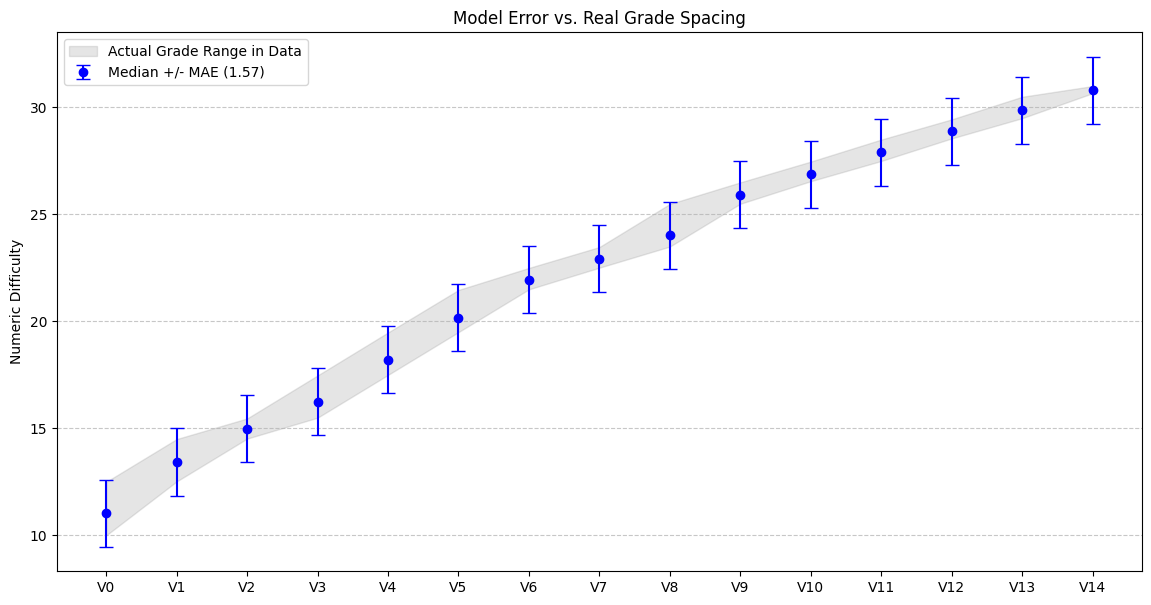

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Calculate MAE since it wasn't stored during training
model.eval()
total_absolute_error = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        total_absolute_error += torch.abs(outputs - targets).sum().item()

mae_value = total_absolute_error / len(val_loader.dataset)
print(f"Calculated Validation MAE: {mae_value:.4f}")

# Calculate median difficulty for each grade
grade_stats = plot_df.groupby('v_grade')['difficulty_numeric'].agg(['median', 'min', 'max']).sort_values('median')

plt.figure(figsize=(14, 7))

# Plot the medians
x_coords = np.arange(len(grade_stats))
plt.errorbar(x_coords, grade_stats['median'],
             yerr=mae_value, fmt='o', color='blue',
             label=f'Median +/- MAE ({mae_value:.2f})', capsize=5)

# Plot the actual data range for each grade to show overlap
plt.fill_between(x_coords, grade_stats['min'], grade_stats['max'], color='gray', alpha=0.2, label='Actual Grade Range in Data')

plt.xticks(x_coords, grade_stats.index)
plt.ylabel('Numeric Difficulty')
plt.title('Model Error vs. Real Grade Spacing')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# Calculate grade-specific sensitivity
grade_stats['points_to_next'] = grade_stats['median'].diff().shift(-1)
grade_stats['mae_in_this_grade_units'] = mae_value / grade_stats['points_to_next']

print("Interpretation:")
print(f"Where the blue error bars overlap multiple gray sections, the model may confuse those grades.")
display(grade_stats[['median', 'points_to_next', 'mae_in_this_grade_units']].dropna())

In [ ]:
import torch

def evaluate_grade_accuracy(model, loader, device, mapping_df):
    model.eval()
    correct_0 = 0
    correct_1 = 0
    correct_2 = 0
    total = 0

    # Get a list of sorted V-grades and their median numeric values
    v_grade_list = grade_stats.index.tolist()
    v_grade_medians = grade_stats['median'].values

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            for pred, actual in zip(outputs.cpu().numpy(), targets.cpu().numpy()):
                # Map numeric prediction and actual to the closest V-grade index
                pred_idx = (np.abs(v_grade_medians - pred)).argmin()
                actual_idx = (np.abs(v_grade_medians - actual)).argmin()

                diff = abs(pred_idx - actual_idx)
                if diff == 0: correct_0 += 1
                if diff <= 1: correct_1 += 1
                if diff <= 2: correct_2 += 1
                total += 1

    print(f"--- V-Grade Accuracy (Val Set) ---")
    print(f"Exact Grade (+- 0): {100*correct_0/total:.2f}%")
    print(f"Within +- 1 Grade:  {100*correct_1/total:.2f}%")
    print(f"Within +- 2 Grades: {100*correct_2/total:.2f}%")

evaluate_grade_accuracy(model, val_loader, device, mapping_df)

--- V-Grade Accuracy (Val Set) ---
Exact Grade (+- 0): 32.46%
Within +- 1 Grade:  77.57%
Within +- 2 Grades: 94.10%


export model for local web use using ONNX

In [ ]:
!pip install -q onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 129.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 21.2 MB/s eta 0:00:00


In [ ]:
import torch
from pathlib import Path

ARTIFACT_DIR = Path("/content/artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
ONNX_PATH = ARTIFACT_DIR / "kilter_grade_regressor.fp32.onnx"

# Make sure model is in eval mode to disable dropout
model.eval()

# Create a dummy input on the correct device with the appropriate input_dim
dummy_input = torch.randn(1, input_dim, dtype=torch.float32).to(device)

# Export the model as a single ONNX file
torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    input_names=["features"],
    output_names=["difficulty"],
    dynamic_axes={
        "features": {0: "batch_size"},
        "difficulty": {0: "batch_size"},
    },
    opset_version=17,
    export_modules_as_functions=True
)
print(f"Model exported to {ONNX_PATH}")

/tmp/ipykernel_964/3075550763.py:15: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0527 13:27:51.246000 964 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ClimbMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ClimbMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to /content/artifacts/kilter_grade_regressor.fp32.onnx


In [ ]:
import onnx
import os

# Load the ONNX model (it will automatically find the .data file in the same dir)
model_proto = onnx.load(str(ONNX_PATH))

# Resave it, forcing all tensors to be packed into the same file
onnx.save(model_proto, str(ONNX_PATH), save_as_external_data=False)

# Remove the old .data file if it exists
data_path = str(ONNX_PATH) + ".data"
if os.path.exists(data_path):
    os.remove(data_path)
    print(f"Merged into single file. Deleted {data_path}")
else:
    print("Already a single file.")

Merged into single file. Deleted /content/artifacts/kilter_grade_regressor.fp32.onnx.data


In [ ]:
import onnxruntime as ort
import numpy as np
import torch

session = ort.InferenceSession(
    str(ONNX_PATH),
    providers=["CPUExecutionProvider"],
)

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print("ONNX input:", input_name, session.get_inputs()[0].shape)
print("ONNX output:", output_name, session.get_outputs()[0].shape)

# Use a small real batch from X_val
x_raw = X_val[:8].astype(np.float32)
# Flatten the input just like the ClimbDataset does before feeding into MLP
x_flat = x_raw.reshape(x_raw.shape[0], -1)

with torch.no_grad():
    # Move to the correct device for PyTorch model inference
    torch_pred = model(torch.from_numpy(x_flat).to(device)).cpu().numpy()

onnx_pred = session.run(
    [output_name],
    {input_name: x_flat},
)[0]

print("torch:", torch_pred[:5].reshape(-1))
print("onnx :", onnx_pred[:5].reshape(-1))

max_diff = np.max(np.abs(torch_pred - onnx_pred))
print("max abs diff:", max_diff)

assert np.allclose(torch_pred, onnx_pred, rtol=1e-4, atol=1e-4), "Predictions do not match!"
print("ONNX verification passed successfully!")

ONNX input: features ['batch_size', 2825]
ONNX output: difficulty ['batch_size', 1]
torch: [23.498875 24.779528 21.483133 20.418123 21.164309]
onnx : [23.49887  24.779522 21.483126 20.418118 21.164299]
max abs diff: 9.536743e-06
ONNX verification passed successfully!


In [ ]:
import json
import re
import torch

# Select a random sample from train_df
sample_row = train_df.sample(n=1, random_state=42).iloc[0]

# 1. Run the sample through the model
x_np = flatten_climb_multihot(sample_row)
x_tensor = torch.tensor(x_np, dtype=torch.float32).view(1, -1).to(device)

model.eval()
with torch.no_grad():
    pred_diff = model(x_tensor).item()

print(f"Climb Name: {sample_row.get('name', 'Unknown')}")
print(f"Actual Difficulty: {sample_row['difficulty_numeric']:.2f} ({sample_row.get('boulder_grade', 'N/A')})")
print(f"Predicted Difficulty: {pred_diff:.5f}")

# 2. Export the sample as a JSON object
frames_str = str(sample_row['frames'])
matches = re.findall(r'p(\d+)r(\d+)', frames_str)

# Create {placementid: typeid}
placements_dict = {int(p): int(r) for p, r in matches}

sample_export = {
    "placements": placements_dict,
    "angle": float(sample_row['angle'])
}

print("\n--- JSON Export ---")
print(json.dumps(sample_export, indent=2))

Climb Name: Guillaume warm up
Actual Difficulty: 10.31 (4a/V0)
Predicted Difficulty: 11.20529

--- JSON Export ---
{
  "placements": {
    "1137": 15,
    "1154": 15,
    "1157": 15,
    "1190": 15,
    "1205": 12,
    "1206": 12,
    "1219": 15,
    "1221": 15,
    "1223": 13,
    "1257": 13,
    "1259": 13,
    "1275": 13,
    "1305": 14,
    "1306": 13,
    "1308": 13
  },
  "angle": 35.0
}


Verify Python Model
(ONNX Verification is done in web/Generator/GeneratorTest.tsx)